In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
train=pd.read_csv("/kaggle/input/titanic/train.csv")
test=pd.read_csv("/kaggle/input/titanic/test.csv")

In [4]:
#train_id=train["PassengerId"]
test_id=test["PassengerId"]

# Data Analysis

## Training dataset

In [5]:
train.describe()  #computes a summary of statistics pertaining to the DataFrame columns(numeric columns only)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
print(train.Pclass.value_counts(dropna=False))
print("--"*50)
print(train.Embarked.value_counts(dropna=False))
print("--"*50)
print(train.SibSp.value_counts(dropna=False))
print("--"*50)
print(train.Parch.value_counts(dropna=False))
print("--"*50)

3    491
1    216
2    184
Name: Pclass, dtype: int64
----------------------------------------------------------------------------------------------------
S      644
C      168
Q       77
NaN      2
Name: Embarked, dtype: int64
----------------------------------------------------------------------------------------------------
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64
----------------------------------------------------------------------------------------------------
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64
----------------------------------------------------------------------------------------------------


In [8]:
#Sort rows of a dataframe in descending order of NaN counts

train.isnull().sum().sort_values(ascending = False)

Cabin          687
Age            177
Embarked         2
Fare             0
Ticket           0
Parch            0
SibSp            0
Sex              0
Name             0
Pclass           0
Survived         0
PassengerId      0
dtype: int64

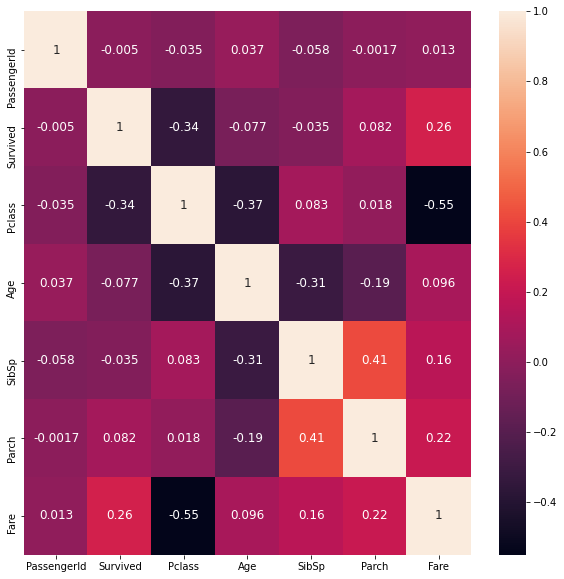

In [9]:
#Analysing the correlation of features 

mat=train.corr()
fig,ax = plt.subplots(figsize = (10,10))
sns.heatmap(mat,annot = True, annot_kws={'size': 12})

## Testing Dataset

In [10]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [11]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [12]:
print(train.Pclass.value_counts(dropna=False))  
print("--"*50)
print(train.Embarked.value_counts())
print("--"*50)
print(train.SibSp.value_counts())
print("--"*50)
print(train.Parch.value_counts())
print("--"*50)

3    491
1    216
2    184
Name: Pclass, dtype: int64
----------------------------------------------------------------------------------------------------
S    644
C    168
Q     77
Name: Embarked, dtype: int64
----------------------------------------------------------------------------------------------------
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64
----------------------------------------------------------------------------------------------------
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64
----------------------------------------------------------------------------------------------------


In [13]:
test.isnull().sum().sort_values(ascending=False)

Cabin          327
Age             86
Fare             1
Embarked         0
Ticket           0
Parch            0
SibSp            0
Sex              0
Name             0
Pclass           0
PassengerId      0
dtype: int64

# Handling missing values

-Dropping the "cabin" column as > 50% values in it are NaN

-Filling the NaN values in other columns.

-Dropping irrelevant columns


In [14]:
del train["Cabin"]    #Deleting a column


In [15]:
train["Age"].fillna(train.Age.mean(),inplace=True)      #Replacing null values with mean value 

In [16]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [17]:
train.isnull().sum().sort_values(ascending=False)

#Embarked has 2 null values acc to the output of this cell

Embarked       2
Fare           0
Ticket         0
Parch          0
SibSp          0
Age            0
Sex            0
Name           0
Pclass         0
Survived       0
PassengerId    0
dtype: int64

In [18]:
#dropping  2 missing values of embarked
train.dropna(inplace=True)




## Testing Dataset

In [19]:
del test["Cabin"]

In [20]:
test["Age"].fillna(test.Age.mean(),inplace=True)

In [21]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,12.634534,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,30.272590,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,35.750000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [22]:
test.isnull().sum().sort_values(ascending=False)

Fare           1
Embarked       0
Ticket         0
Parch          0
SibSp          0
Age            0
Sex            0
Name           0
Pclass         0
PassengerId    0
dtype: int64

In [23]:
# As we cannot remove a value from test data we have to fill the missing value of fare
test.fillna(test.Fare.median(),inplace=True)
test.isnull().sum().sort_values(ascending=False)

Embarked       0
Fare           0
Ticket         0
Parch          0
SibSp          0
Age            0
Sex            0
Name           0
Pclass         0
PassengerId    0
dtype: int64

# Feature Engineering

## Training dataset

In [24]:
Y=train["Survived"]

In [25]:
del train["PassengerId"]
del test["PassengerId"]

In [26]:
del train["Survived"]

In [27]:
train.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [28]:
train.shape

(889, 9)

In [29]:
test.shape

(418, 9)

In [30]:
test.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [31]:
#Joining the two datasets 

final=pd.concat([train,test],axis =0)  

In [32]:
final.shape

(1307, 9)

In [33]:
final.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [34]:
#improved 15% accuracy

def One_hot_encoding(columns):
    final_df=final
    i=0
    for fields in columns:
        col1=pd.get_dummies(final[fields],drop_first=True)   # drops the first col out of all created columns
        
        final.drop([fields],axis=1,inplace=True)   # that col itself is dropped 
        if i==0:
            final_df=col1.copy()
        else:           
            final_df=pd.concat([final_df,col1],axis=1)
        i=i+1
       
        
    final_df=pd.concat([final,final_df],axis=1)
        
    return final_df

In [35]:
columns=["Sex","Embarked","Pclass","Parch"]   #those cols are put who have a significant effect on survival as seen from heat map

In [36]:
df_final = One_hot_encoding(columns)

In [37]:
df_final.head()

,Name,Age,SibSp,Ticket,Fare,male,Q,S,2,3,1,2,3,4,5,6,9
0,"Braund, Mr. Owen Harris",22.0,1,A/5 21171,7.2500,1,0,1,0,1,0,0,0,0,0,0,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,PC 17599,71.2833,0,0,0,0,0,0,0,0,0,0,0,0
2,"Heikkinen, Miss. Laina",26.0,0,STON/O2. 3101282,7.9250,0,0,1,0,1,0,0,0,0,0,0,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,113803,53.1000,0,0,1,0,0,0,0,0,0,0,0,0
4,"Allen, Mr. William Henry",35.0,0,373450,8.0500,1,0,1,0,1,0,0,0,0,0,0,0


In [38]:
df_final.drop("Name",axis=1,inplace=True)
df_final.drop("Ticket",axis=1,inplace=True)


In [39]:
df_final.head()

,Age,SibSp,Fare,male,Q,S,2,3,1,2,3,4,5,6,9
0,22.0,1,7.2500,1,0,1,0,1,0,0,0,0,0,0,0
1,38.0,1,71.2833,0,0,0,0,0,0,0,0,0,0,0,0
2,26.0,0,7.9250,0,0,1,0,1,0,0,0,0,0,0,0
3,35.0,1,53.1000,0,0,1,0,0,0,0,0,0,0,0,0
4,35.0,0,8.0500,1,0,1,0,1,0,0,0,0,0,0,0


## Normalising datasets

In [40]:

from sklearn import preprocessing

# Get column names first
names = df_final.columns

# Create the Scaler object
scaler = preprocessing.StandardScaler()

# Fit your data on the scaler object
scaled_df = scaler.fit_transform(df_final)
df_final = pd.DataFrame(scaled_df, columns=names)

In [41]:
#Making col name as 1.. 2 .. 3 so that there are no repeating column names 


cols = []
count = 1
for column in df_final.columns:
    cols.append(count)
    count+=1
    continue
    


In [42]:
cols

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [43]:
df_final.columns = cols

In [44]:
df_final.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-0.610722,0.480272,-0.501839,0.741900,-0.322312,0.655727,-0.518587,0.918391,-0.386673,-0.307636,-0.078477,-0.067911,-0.067911,-0.039148,-0.039148
1,0.633830,0.480272,0.736023,-1.347891,-0.322312,-1.525025,-0.518587,-1.088861,-0.386673,-0.307636,-0.078477,-0.067911,-0.067911,-0.039148,-0.039148
2,-0.299584,-0.479537,-0.488790,-1.347891,-0.322312,0.655727,-0.518587,0.918391,-0.386673,-0.307636,-0.078477,-0.067911,-0.067911,-0.039148,-0.039148
3,0.400477,0.480272,0.384512,-1.347891,-0.322312,0.655727,-0.518587,-1.088861,-0.386673,-0.307636,-0.078477,-0.067911,-0.067911,-0.039148,-0.039148
4,0.400477,-0.479537,-0.486373,0.741900,-0.322312,0.655727,-0.518587,0.918391,-0.386673,-0.307636,-0.078477,-0.067911,-0.067911,-0.039148,-0.039148


## Spliting into train and test again

In [45]:
df_train=df_final.iloc[:889,:]   
df_test=df_final.iloc[889:,:]

In [46]:
X=df_train

In [47]:
df_test.shape

(418, 15)

# Modeling

## Applying Random Foresting

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y)

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
#RandomForestClassifier?

In [51]:
model_rforest = RandomForestClassifier()
model_rforest.fit(X_train,Y_train)

RandomForestClassifier()

In [52]:
print("R-Squared Value for Training Set: {:.3f}".format(model_rforest.score(X_train,Y_train)))   #Returns the mean accuracy of the given test data
print("R-Squared Value for Test Set: {:.3f}".format(model_rforest.score(X_test,Y_test)))

R-Squared Value for Training Set: 0.979
R-Squared Value for Test Set: 0.807


In [53]:
predictions_01 = model_rforest.predict(df_test)  

In [54]:
output_02 = pd.DataFrame({'PassengerId': test_id, 'Survived': predictions_01})
output_02.to_csv('Titanic_RF.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


## Applying desicion Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier

In [56]:
model_dec = DecisionTreeClassifier()
model_dec.fit(X_train, Y_train)

DecisionTreeClassifier()

In [57]:
print("R-Squared Value for Training Set: {:.3f}".format(model_dec.score(X_train,Y_train)))
print("R-Squared Value for Test Set: {:.3f}".format(model_dec.score(X_test,Y_test)))

R-Squared Value for Training Set: 0.979
R-Squared Value for Test Set: 0.771


In [58]:
predictions_02 = model_dec.predict(df_test)

In [59]:
output_02 = pd.DataFrame({'PassengerId': test_id, 'Survived': predictions_02})
output_02.to_csv('Titanic_DT.csv',  index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
